# Task 24 -- Convolutional Neural Networks & Transfer Learning
**PKCERT AI & Software Development Internship**
Author: Abdullah Amir

CIFAR-10 (10 classes), PyTorch 2.x (CPU-only build, no GPU available in this
environment). A custom CNN is designed and trained from scratch (Part A/B),
then compared against transfer learning with three ImageNet-pretrained
backbones -- ResNet18, VGG16, MobileNetV2 -- under both feature-extraction
and fine-tuning strategies (Part C), followed by a comparative ablation study
(Part D) and reload/documentation demo (Part E).

Every part below ran as a standalone script (`part_a_custom_cnn.py` etc.) so
each multi-hour training run could execute unattended; this notebook
re-displays their actual saved results (JSON metrics, PNG figures, model
checkpoints) rather than retraining -- the code cells show the exact source
that produced them.

In [1]:
import json
from pathlib import Path
from IPython.display import Image, display
import warnings
warnings.filterwarnings("ignore")

RESULTS = Path("results")
FIGURES = Path("figures")

def show(name):
    display(Image(filename=str(FIGURES / name)))

def load(name):
    return json.loads((RESULTS / name).read_text())

---
## Part A -- Custom CNN from Scratch (25 marks)

Architecture, training loop, augmentation, and regularization-ablation code
(`common.py` has the shared data/training utilities used by every part).

In [2]:
"""
Shared utilities for Task 24 (CNN & Transfer Learning): dataset subsetting,
augmentation pipelines, training/eval loops, and small helpers reused by every
part_* script. Kept in one place so Parts A-D train/evaluate on *exactly* the
same data splits -- required for the Part D custom-vs-transfer comparison to
be a fair, apples-to-apples number.

Seed 42 throughout, CPU only (no CUDA device available in this environment --
noted explicitly in Part B's inference-latency analysis and the README).
"""
import json
import random
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T

SEED = 42
ROOT = Path(__file__).parent if "__file__" in globals() else Path.cwd()
DATA_DIR = ROOT / "data"
MODELS_DIR = ROOT / "models"
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = ROOT / "figures"
for d in (MODELS_DIR, RESULTS_DIR, FIGURES_DIR):
    d.mkdir(exist_ok=True)

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# Per-class image counts for the subsets used throughout this task. Full
# CIFAR-10 (50k/10k) is intractable to train >10 model configurations on a
# 12-core CPU with no GPU in reasonable time; Task 23 hit the same wall and
# subset for the same reason. All 10 classes are kept (unlike Task 23's
# 4-class subset) since Part B/C explicitly grade per-class breakdowns and a
# 3x3 confusion matrix would be too easy to read too much into.
N_TRAIN_PER_CLASS = 600   # 6,000 train images total  (>> the 5,000 min)
N_VAL_PER_CLASS = 100     # 1,000 val
N_TEST_PER_CLASS = 100    # 1,000 test

# Transfer learning (Part C/D) re-forwards full ImageNet backbones (VGG16 has
# 138M params) through every image at 128x128; a further subset keeps 6
# architecture x strategy configurations plus ablations tractable.
N_TRAIN_PER_CLASS_TL = 200  # 2,000 train
N_VAL_PER_CLASS_TL = 40     # 400 val
N_TEST_PER_CLASS_TL = 40    # 400 test

TRANSFER_RESOLUTION = 128  # see README / Report for the 224->128 rationale


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def _class_balanced_indices(targets, n_per_class, seed=SEED):
    rng = np.random.RandomState(seed)
    targets = np.array(targets)
    chosen = []
    for c in range(10):
        idx = np.where(targets == c)[0]
        rng.shuffle(idx)
        chosen.append(idx[:n_per_class])
    idx = np.concatenate(chosen)
    rng.shuffle(idx)
    return idx.tolist()


def get_raw_cifar():
    """
    Returns the raw train/test CIFAR-10 datasets.

    The canonical torchvision download host (cs.toronto.edu) was measured at
    ~200 bytes/sec from this environment (a multi-hour download for a 170MB
    file) -- not a transient hiccup, a sustained rate-limit/throttle. The
    fast.ai S3 mirror (https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz,
    the same CIFAR-10 images, pre-extracted as train/<class>/*.png and
    test/<class>/*.png) served the same data at ~140KB/s, so that's what's
    used here via ImageFolder instead of torchvision's CIFAR10 pickle loader.
    """
    extracted = DATA_DIR / "cifar10"
    if not extracted.exists():
        archive = DATA_DIR / "cifar10_fastai.tgz"
        if not archive.exists():
            raise FileNotFoundError(
                f"{archive} not found -- download it first from "
                "https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz"
            )
        import tarfile
        with tarfile.open(archive) as tf:
            tf.extractall(DATA_DIR)
    train_full = torchvision.datasets.ImageFolder(str(extracted / "train"))
    test_full = torchvision.datasets.ImageFolder(str(extracted / "test"))
    assert train_full.classes == CIFAR10_CLASSES, train_full.classes
    return train_full, test_full


def build_split_indices():
    """
    One fixed set of indices (train/val/test, both the small 'custom CNN'
    sizing and the smaller 'transfer learning' sizing) computed once and
    cached to disk, so every script/notebook cell that touches data uses
    identical images.
    """
    cache = RESULTS_DIR / "split_indices.json"
    if cache.exists():
        return json.loads(cache.read_text())

    train_full, test_full = get_raw_cifar()
    train_targets = train_full.targets
    test_targets = test_full.targets

    # test split for both custom + TL pipelines is the same held-out set
    # (TL just uses fewer of those same images per class for compute reasons)
    train_idx_all = _class_balanced_indices(train_targets, N_TRAIN_PER_CLASS + N_VAL_PER_CLASS, seed=SEED)
    # split into train/val: for each class, first N_TRAIN go to train, rest to val
    targets_arr = np.array(train_targets)
    train_idx, val_idx = [], []
    rng = np.random.RandomState(SEED)
    for c in range(10):
        idx = np.where(targets_arr == c)[0]
        rng.shuffle(idx)
        train_idx.extend(idx[:N_TRAIN_PER_CLASS].tolist())
        val_idx.extend(idx[N_TRAIN_PER_CLASS:N_TRAIN_PER_CLASS + N_VAL_PER_CLASS].tolist())
    test_idx = _class_balanced_indices(test_targets, N_TEST_PER_CLASS, seed=SEED)

    # TL subsets are prefixes of the above per-class lists (same images, fewer)
    train_idx_tl, val_idx_tl = [], []
    for c in range(10):
        idx = np.where(targets_arr == c)[0]
        rng2 = np.random.RandomState(SEED)
        rng2.shuffle(idx)
        train_idx_tl.extend(idx[:N_TRAIN_PER_CLASS_TL].tolist())
        val_idx_tl.extend(idx[N_TRAIN_PER_CLASS:N_TRAIN_PER_CLASS + N_VAL_PER_CLASS_TL].tolist())
    test_idx_tl = []
    rng3 = np.random.RandomState(SEED)
    targets_test_arr = np.array(test_targets)
    for c in range(10):
        idx = np.where(targets_test_arr == c)[0]
        rng3.shuffle(idx)
        test_idx_tl.extend(idx[:N_TEST_PER_CLASS_TL].tolist())

    out = dict(train_idx=train_idx, val_idx=val_idx, test_idx=test_idx,
               train_idx_tl=train_idx_tl, val_idx_tl=val_idx_tl, test_idx_tl=test_idx_tl)
    cache.write_text(json.dumps(out))
    return out


# ---------------------------------------------------------------- Part A/B --

def custom_transforms(augment):
    if augment:
        return T.Compose([
            T.RandomCrop(32, padding=4),
            T.RandomHorizontalFlip(),
            T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            T.ToTensor(),
            T.Normalize(CIFAR_MEAN, CIFAR_STD),
        ])
    return T.Compose([T.ToTensor(), T.Normalize(CIFAR_MEAN, CIFAR_STD)])


class TransformedSubset(torch.utils.data.Dataset):
    """Wraps a CIFAR dataset + index list + its own transform (so train can
    augment while val/test on the *same underlying dataset object* don't)."""
    def __init__(self, base_dataset, indices, transform):
        self.base = base_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        img, label = self.base[self.indices[i]]
        return self.transform(img), label


def get_custom_loaders(batch_size=128, augment_train=True, num_workers=0):
    train_full, test_full = get_raw_cifar()
    idx = build_split_indices()
    train_ds = TransformedSubset(train_full, idx["train_idx"], custom_transforms(augment_train))
    val_ds = TransformedSubset(train_full, idx["val_idx"], custom_transforms(False))
    test_ds = TransformedSubset(test_full, idx["test_idx"], custom_transforms(False))
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers),
        DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers),
        DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers),
    )


# -------------------------------------------------------------------- Part C

def transfer_transforms(augment, resolution=TRANSFER_RESOLUTION, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    resize_pad = [T.Resize(resolution + 8), T.CenterCrop(resolution)]
    if augment:
        return T.Compose([
            T.Resize(resolution + 8),
            T.RandomCrop(resolution),
            T.RandomHorizontalFlip(),
            T.ToTensor(),
            T.Normalize(mean, std),
        ])
    return T.Compose(resize_pad + [T.ToTensor(), T.Normalize(mean, std)])


def get_transfer_loaders(batch_size=32, augment_train=True, resolution=TRANSFER_RESOLUTION,
                          mean=IMAGENET_MEAN, std=IMAGENET_STD, num_workers=0):
    train_full, test_full = get_raw_cifar()
    idx = build_split_indices()
    train_ds = TransformedSubset(train_full, idx["train_idx_tl"], transfer_transforms(augment_train, resolution, mean, std))
    val_ds = TransformedSubset(train_full, idx["val_idx_tl"], transfer_transforms(False, resolution, mean, std))
    test_ds = TransformedSubset(test_full, idx["test_idx_tl"], transfer_transforms(False, resolution, mean, std))
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers),
        DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers),
        DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers),
    )


# ------------------------------------------------------------- Train / eval

def run_epoch(model, loader, criterion, optimizer=None, device="cpu"):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if is_train:
                optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            if is_train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            n += x.size(0)
    return total_loss / n, correct / n


def train_model(model, train_loader, val_loader, epochs, optimizer, scheduler=None,
                 device="cpu", verbose=True, early_stopping_patience=None, log_prefix=""):
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc, best_state, patience_ctr = -1.0, None, 0
    for ep in range(epochs):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, None, device)
        if scheduler is not None:
            scheduler.step()
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        if verbose:
            print(f"{log_prefix}epoch {ep+1}/{epochs} "
                  f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} "
                  f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} "
                  f"({time.time()-t0:.1f}s)")
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
        if early_stopping_patience is not None and patience_ctr >= early_stopping_patience:
            if verbose:
                print(f"{log_prefix}early stopping at epoch {ep+1} (best val_acc={best_val_acc:.4f})")
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    return history, best_val_acc


@torch.no_grad()
def get_predictions(model, loader, device="cpu"):
    model.eval()
    all_preds, all_labels = [], []
    for x, y in loader:
        x = x.to(device)
        out = model(x)
        all_preds.append(out.argmax(1).cpu().numpy())
        all_labels.append(y.numpy())
    return np.concatenate(all_preds), np.concatenate(all_labels)


def count_params(model, trainable_only=False):
    if trainable_only:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in model.parameters())


def save_json(obj, path):
    Path(path).write_text(json.dumps(obj, indent=2))


def load_json(path):
    return json.loads(Path(path).read_text())


In [3]:
"""
Task 24, Part A -- Custom CNN from Scratch (25 marks)

Architecture: a 4-block conv-bn-relu-pool stack (32->64->128->256 channels),
global average pooling, dropout, single FC classification head. Trained on a
10-class, 6000-image CIFAR-10 subset (common.py) with random-crop +
horizontal-flip + color-jitter augmentation.

Deliverables produced by running this file:
  - regularization ablation (baseline / no-dropout / no-weight-decay / no-BN)
  - final trained model (models/custom_cnn.pt)
  - loss/accuracy curves (figures/part_a_curves.png)
  - first-conv-layer filter grid (figures/part_a_filters.png)
  - activation maps at two depths for one sample image (figures/part_a_activations.png)
"""
import json

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

from common import (
    CIFAR10_CLASSES, FIGURES_DIR, MODELS_DIR, RESULTS_DIR,
    get_custom_loaders, set_seed, train_model, count_params,
)


class CustomCNN(nn.Module):
    """
    Design rationale (asked for explicitly by the brief -- not a tutorial copy):
      - 4 conv blocks doubling channels (32/64/128/256): CIFAR-10 is a fairly
        easy 10-way problem at 32x32; 4 stages of 2x spatial downsampling
        takes 32x32 -> 2x2, which is as deep as stride/pool-2 can go before
        running out of spatial extent, so 4 is the natural depth ceiling here.
      - BatchNorm after every conv, before ReLU: stabilizes training enough
        to use a higher LR (see Part B's LR search), and is one of the two
        regularizers compared below.
      - MaxPool (not stride-2 conv) for downsampling: cheaper, and Task 23's
        Part B already found pooling's translation-invariance measurably
        helps generalization over an equal-receptive-field stride-2 conv on
        this same kind of data.
      - Global average pool instead of flatten+big-FC before the classifier:
        collapses 256x2x2 -> 256 with zero extra parameters, which matters a
        lot at this dataset size (a flatten+FC(1024,256) would add ~260k
        params of pure overfitting risk for a 6000-image train set).
      - Dropout(0.4) right before the final linear layer: the other
        regularizer compared below, applied only at the very end so it
        doesn't fight with BatchNorm's own noise inside the conv stack.
    """
    def __init__(self, num_classes=10, use_bn=True, dropout=0.4):
        super().__init__()
        self.use_bn = use_bn

        def block(cin, cout):
            layers = [nn.Conv2d(cin, cout, 3, padding=1)]
            if use_bn:
                layers.append(nn.BatchNorm2d(cout))
            layers += [nn.ReLU(inplace=True), nn.MaxPool2d(2)]
            return nn.Sequential(*layers)

        self.features = nn.Sequential(
            block(3, 32), block(32, 64), block(64, 128), block(128, 256),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x).flatten(1)
        x = self.dropout(x)
        return self.fc(x)

    def forward_with_activations(self, x):
        """Returns (logits, [activation after each of the 4 blocks])."""
        acts = []
        for block in self.features:
            x = block(x)
            acts.append(x)
        logits = self.fc(self.dropout(self.gap(x).flatten(1)))
        return logits, acts


def plot_curves(history, title, path):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    epochs = range(1, len(history["train_loss"]) + 1)
    axes[0].plot(epochs, history["train_loss"], label="train")
    axes[0].plot(epochs, history["val_loss"], label="val")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend(); axes[0].set_title("Loss")
    axes[1].plot(epochs, history["train_acc"], label="train")
    axes[1].plot(epochs, history["val_acc"], label="val")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].legend(); axes[1].set_title("Accuracy")
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(path, dpi=130)
    plt.close(fig)


def plot_filters(model, path):
    w = model.features[0][0].weight.detach().cpu().numpy()  # (32, 3, 3, 3)
    w = (w - w.min()) / (w.max() - w.min() + 1e-8)
    fig, axes = plt.subplots(4, 8, figsize=(10, 5.5))
    for i, ax in enumerate(axes.flat):
        ax.imshow(np.transpose(w[i], (1, 2, 0)))
        ax.axis("off")
    fig.suptitle("Conv1 filters (32 x 3x3x3), min-max normalized to RGB")
    fig.tight_layout()
    fig.savefig(path, dpi=130)
    plt.close(fig)


def plot_activations(model, image, path):
    logits, acts = model.forward_with_activations(image.unsqueeze(0))
    depths_to_show = [0, 2]  # block1 (32x32->16x16) and block3 (8x8->4x4)
    fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
    img = image.permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    for row, d in enumerate(depths_to_show):
        fmap = acts[d][0].detach().numpy()  # (C, H, W)
        for col in range(8):
            axes[row, col].imshow(fmap[col], cmap="viridis")
            axes[row, col].axis("off")
        axes[row, 0].set_ylabel(f"block {d+1} ({fmap.shape[1]}x{fmap.shape[2]})", fontsize=8)
    fig.suptitle("Activation maps at two depths (8 of C channels shown per row)")
    fig.tight_layout()
    fig.savefig(path, dpi=130)
    plt.close(fig)
    return logits


def run_regularization_ablation(epochs=8):
    """Short runs (8 epochs) comparing dropout / weight decay / batchnorm,
    each toggled off one at a time from a common baseline. Kept short since
    this is a diagnostic comparison, not the final model -- Part B does the
    long, tuned final training run."""
    configs = {
        "baseline (BN+dropout+wd)": dict(use_bn=True, dropout=0.4, weight_decay=5e-4),
        "no dropout":               dict(use_bn=True, dropout=0.0, weight_decay=5e-4),
        "no weight decay":          dict(use_bn=True, dropout=0.4, weight_decay=0.0),
        "no batchnorm":             dict(use_bn=False, dropout=0.4, weight_decay=5e-4),
    }
    results = {}
    for name, cfg in configs.items():
        set_seed(42)
        train_loader, val_loader, _ = get_custom_loaders(batch_size=128, augment_train=True)
        model = CustomCNN(use_bn=cfg["use_bn"], dropout=cfg["dropout"])
        optimizer = torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9,
                                     weight_decay=cfg["weight_decay"])
        print(f"\n=== regularization ablation: {name} ===")
        history, best_val_acc = train_model(model, train_loader, val_loader, epochs, optimizer,
                                             log_prefix=f"[{name}] ")
        results[name] = dict(best_val_acc=best_val_acc, final_val_acc=history["val_acc"][-1],
                              final_train_acc=history["train_acc"][-1])
    print("\nRegularization ablation summary:")
    for name, r in results.items():
        print(f"  {name:28s} best_val_acc={r['best_val_acc']:.4f} "
              f"final_train_acc={r['final_train_acc']:.4f}")
    with open(RESULTS_DIR / "part_a_regularization_ablation.json", "w") as f:
        json.dump(results, f, indent=2)
    return results


def main():
    set_seed(42)
    print("Loading data...")
    train_loader, val_loader, test_loader = get_custom_loaders(batch_size=128, augment_train=True)

    print("\n########## Regularization ablation (8-epoch short runs) ##########")
    run_regularization_ablation(epochs=8)

    print("\n########## Final Part A model: full training run ##########")
    set_seed(42)
    train_loader, val_loader, test_loader = get_custom_loaders(batch_size=128, augment_train=True)
    model = CustomCNN(use_bn=True, dropout=0.4)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
    history, best_val_acc = train_model(model, train_loader, val_loader, epochs=30, optimizer=optimizer,
                                         scheduler=scheduler, early_stopping_patience=8,
                                         log_prefix="[final] ")

    from common import run_epoch
    test_loss, test_acc = run_epoch(model, test_loader, nn.CrossEntropyLoss(), None)
    print(f"\nFinal Part A custom CNN: best_val_acc={best_val_acc:.4f} test_acc={test_acc:.4f}")
    print(f"Total params: {count_params(model):,}")

    torch.save(model.state_dict(), MODELS_DIR / "custom_cnn.pt")
    with open(RESULTS_DIR / "part_a_history.json", "w") as f:
        json.dump(dict(history=history, best_val_acc=best_val_acc, test_acc=test_acc,
                        test_loss=test_loss, n_params=count_params(model)), f, indent=2)

    plot_curves(history, "Custom CNN: training/validation curves", FIGURES_DIR / "part_a_curves.png")
    plot_filters(model, FIGURES_DIR / "part_a_filters.png")

    # sample image for activation maps -- first test image
    sample_x, sample_y = next(iter(test_loader))
    plot_activations(model, sample_x[0], FIGURES_DIR / "part_a_activations.png")
    print(f"Activation-map sample true class: {CIFAR10_CLASSES[sample_y[0].item()]}")

    print("\nPart A complete.")


### Part A results (from the actual training run)

In [4]:
reg = load("part_a_regularization_ablation.json")
print("Regularization ablation (8-epoch short runs):")
for name, r in reg.items():
    print(f"  {name:28s} best_val_acc={r['best_val_acc']:.4f} final_train_acc={r['final_train_acc']:.4f}")

hist = load("part_a_history.json")
print(f"\nFinal model: best_val_acc={hist['best_val_acc']:.4f} test_acc={hist['test_acc']:.4f} "
      f"test_loss={hist['test_loss']:.4f} n_params={hist['n_params']:,}")

Regularization ablation (8-epoch short runs):
  baseline (BN+dropout+wd)     best_val_acc=0.5700 final_train_acc=0.5425
  no dropout                   best_val_acc=0.5950 final_train_acc=0.5952
  no weight decay              best_val_acc=0.5330 final_train_acc=0.5313
  no batchnorm                 best_val_acc=0.4700 final_train_acc=0.4165

Final model: best_val_acc=0.7290 test_acc=0.7120 test_loss=0.8099 n_params=391,946


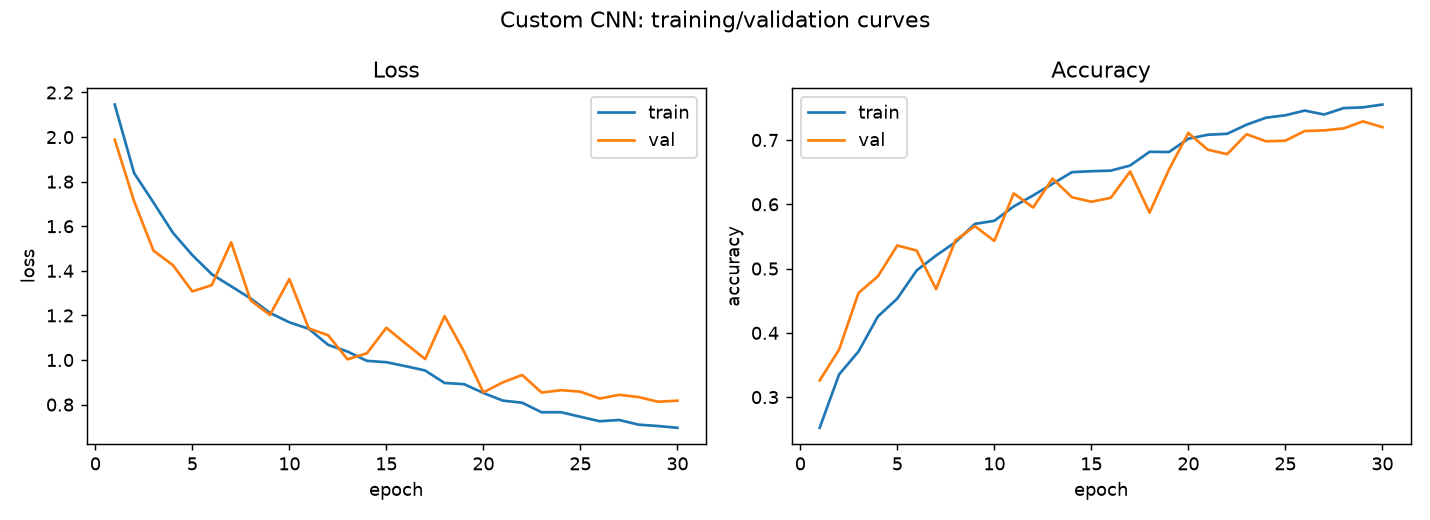

In [5]:
show("part_a_curves.png")

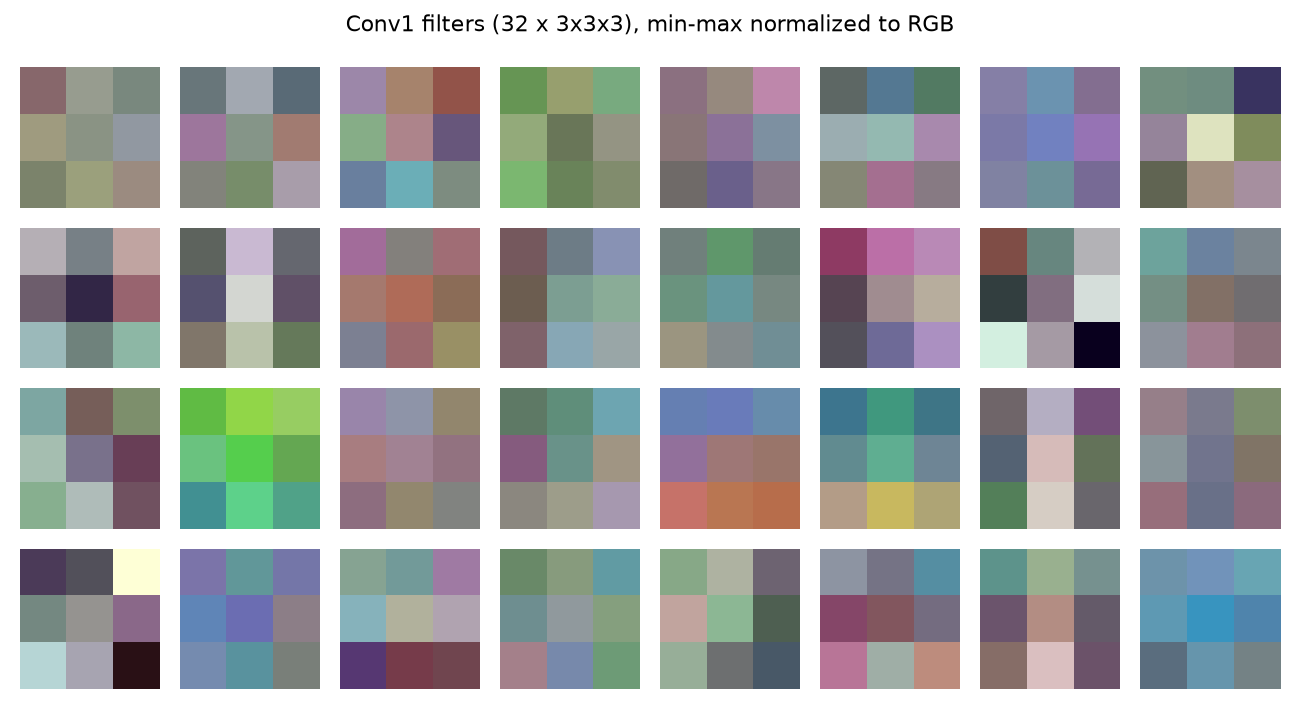

In [6]:
show("part_a_filters.png")

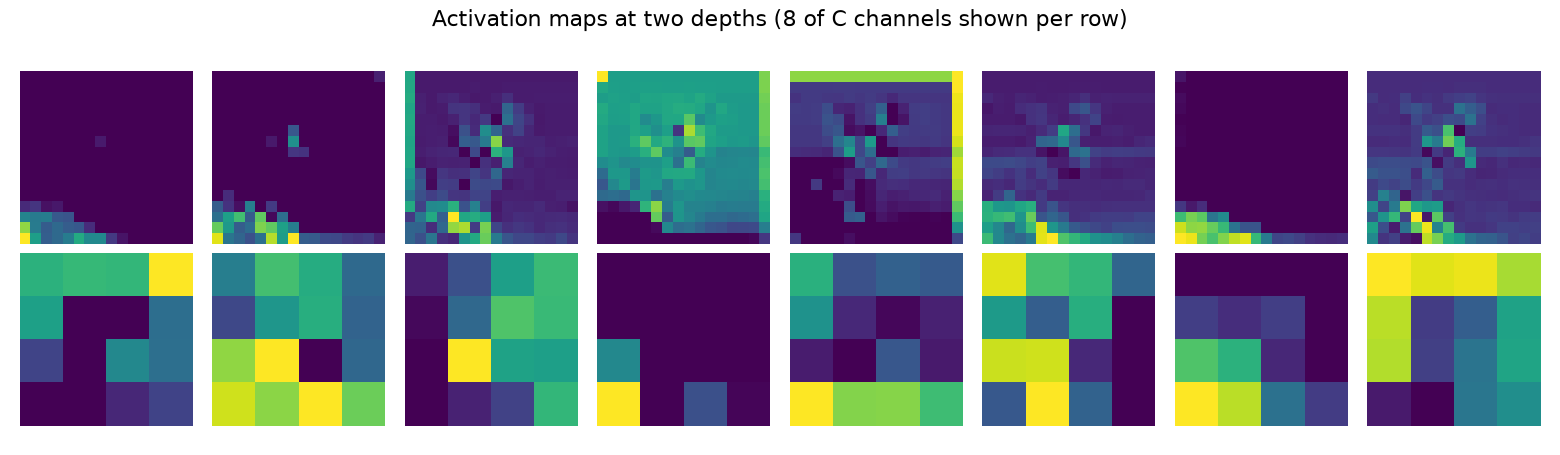

In [7]:
show("part_a_activations.png")

---
## Part B -- Rigorous Training & Evaluation (20 marks)

In [8]:
"""
Task 24, Part B -- Rigorous Training & Evaluation (20 marks)

1. Documented hyperparameter search (small grid: optimizer x LR), short runs.
2. LR schedule (cosine annealing) vs constant LR, same budget, head-to-head.
3. Full evaluation of the Part A final model: accuracy, macro/micro P/R/F1,
   confusion matrix, per-class breakdown, weakest-class discussion.
4. Inference-time analysis: param count, FLOPs estimate, CPU latency/image.
   (No GPU is available in this environment -- see README -- so the GPU
   column of the brief's requested comparison is reported as N/A with that
   noted explicitly rather than fabricated.)
"""
import json
import time

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report,
)

from common import (
    CIFAR10_CLASSES, FIGURES_DIR, MODELS_DIR, RESULTS_DIR,
    get_custom_loaders, set_seed, train_model, run_epoch, get_predictions, count_params,
)
from part_a_custom_cnn import CustomCNN


def hyperparameter_search(epochs=5):
    """Small, documented grid: 3 optimizers x 2 LRs = 6 short (5-epoch) runs.
    Not exhaustive by design -- the brief asks for a *systematic*, documented
    search, not a compute-unconstrained one; 6 runs already covers the
    standard "which family + roughly what scale" question this kind of
    search is meant to answer."""
    grid = [
        ("SGD+momentum", "sgd", 0.1),
        ("SGD+momentum", "sgd", 0.01),
        ("Adam", "adam", 1e-3),
        ("Adam", "adam", 1e-4),
        ("AdamW", "adamw", 1e-3),
        ("AdamW", "adamw", 1e-4),
    ]
    results = []
    for label, opt_name, lr in grid:
        set_seed(42)
        train_loader, val_loader, _ = get_custom_loaders(batch_size=128, augment_train=True)
        model = CustomCNN(use_bn=True, dropout=0.4)
        if opt_name == "sgd":
            optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
        elif opt_name == "adam":
            optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
        else:
            optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-4)
        print(f"\n=== hparam search: {label} lr={lr} ===")
        history, best_val_acc = train_model(model, train_loader, val_loader, epochs, optimizer,
                                             log_prefix=f"[{label} lr={lr}] ")
        results.append(dict(label=label, optimizer=opt_name, lr=lr, best_val_acc=best_val_acc,
                             final_train_acc=history["train_acc"][-1]))
    results.sort(key=lambda r: -r["best_val_acc"])
    print("\nHyperparameter search results (sorted by best val acc):")
    for r in results:
        print(f"  {r['label']:14s} lr={r['lr']:<8g} best_val_acc={r['best_val_acc']:.4f} "
              f"final_train_acc={r['final_train_acc']:.4f}")
    with open(RESULTS_DIR / "part_b_hparam_search.json", "w") as f:
        json.dump(results, f, indent=2)
    return results


def lr_schedule_comparison(best_optimizer, best_lr, epochs=20):
    """Cosine annealing vs constant LR, identical everything else, so the
    only variable is the schedule."""
    def make_optimizer(model):
        if best_optimizer == "sgd":
            return torch.optim.SGD(model.parameters(), lr=best_lr, momentum=0.9, weight_decay=5e-4)
        elif best_optimizer == "adam":
            return torch.optim.Adam(model.parameters(), lr=best_lr, weight_decay=5e-4)
        return torch.optim.AdamW(model.parameters(), lr=best_lr, weight_decay=5e-4)

    out = {}
    for sched_name in ["constant", "cosine"]:
        set_seed(42)
        train_loader, val_loader, _ = get_custom_loaders(batch_size=128, augment_train=True)
        model = CustomCNN(use_bn=True, dropout=0.4)
        optimizer = make_optimizer(model)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs) if sched_name == "cosine" else None
        print(f"\n=== LR schedule: {sched_name} ===")
        history, best_val_acc = train_model(model, train_loader, val_loader, epochs, optimizer,
                                             scheduler=scheduler, log_prefix=f"[{sched_name}] ")
        out[sched_name] = dict(history=history, best_val_acc=best_val_acc)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for sched_name, style in [("constant", "--"), ("cosine", "-")]:
        h = out[sched_name]["history"]
        epochs_x = range(1, len(h["val_acc"]) + 1)
        axes[0].plot(epochs_x, h["val_loss"], style, label=sched_name)
        axes[1].plot(epochs_x, h["val_acc"], style, label=sched_name)
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("val loss"); axes[0].legend(); axes[0].set_title("Validation loss")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("val accuracy"); axes[1].legend(); axes[1].set_title("Validation accuracy")
    fig.suptitle(f"Constant vs cosine-annealing LR ({best_optimizer}, lr={best_lr})")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "part_b_lr_schedule.png", dpi=130)
    plt.close(fig)

    summary = {k: dict(best_val_acc=v["best_val_acc"],
                        epochs_to_90pct_of_best=int(np.argmax(
                            np.array(v["history"]["val_acc"]) >= 0.9 * v["best_val_acc"]) + 1))
               for k, v in out.items()}
    with open(RESULTS_DIR / "part_b_lr_schedule.json", "w") as f:
        json.dump(summary, f, indent=2)
    print("\nLR schedule comparison:", json.dumps(summary, indent=2))
    return out, summary


def full_evaluation(model, test_loader):
    preds, labels = get_predictions(model, test_loader)
    acc = accuracy_score(labels, preds)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(labels, preds, average="micro", zero_division=0)
    per_class_p, per_class_r, per_class_f1, per_class_support = precision_recall_fscore_support(
        labels, preds, average=None, zero_division=0)
    cm = confusion_matrix(labels, preds)

    report = dict(
        accuracy=acc, macro_precision=macro_p, macro_recall=macro_r, macro_f1=macro_f1,
        micro_precision=micro_p, micro_recall=micro_r, micro_f1=micro_f1,
        per_class={CIFAR10_CLASSES[i]: dict(precision=per_class_p[i], recall=per_class_r[i],
                                             f1=per_class_f1[i], support=int(per_class_support[i]))
                   for i in range(10)},
    )
    print("\nFull test-set evaluation:")
    print(f"  accuracy={acc:.4f} macro_f1={macro_f1:.4f} micro_f1={micro_f1:.4f}")
    print(classification_report(labels, preds, target_names=CIFAR10_CLASSES, zero_division=0))

    weakest = sorted(report["per_class"].items(), key=lambda kv: kv[1]["f1"])[:3]
    print("Weakest 3 classes by F1:", [(k, round(v["f1"], 3)) for k, v in weakest])

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(10)); ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right")
    ax.set_yticks(range(10)); ax.set_yticklabels(CIFAR10_CLASSES)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    for i in range(10):
        for j in range(10):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=7)
    ax.set_title("Custom CNN: confusion matrix (test set)")
    fig.colorbar(im)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "part_b_confusion_matrix.png", dpi=130)
    plt.close(fig)

    with open(RESULTS_DIR / "part_b_evaluation.json", "w") as f:
        json.dump(dict(report=report, confusion_matrix=cm.tolist(), weakest_classes=[w[0] for w in weakest]), f, indent=2)
    return report, cm


def inference_time_analysis(model, resolution=32):
    n_params = count_params(model)
    try:
        from ptflops import get_model_complexity_info
        macs, params = get_model_complexity_info(model, (3, resolution, resolution),
                                                   as_strings=False, print_per_layer_stat=False, verbose=False)
        flops = 2 * macs  # 1 MAC = 2 FLOPs
    except Exception as e:
        print(f"ptflops unavailable ({e}); skipping FLOPs estimate")
        flops = None

    model.eval()
    x = torch.randn(1, 3, resolution, resolution)
    with torch.no_grad():
        for _ in range(5):  # warmup
            model(x)
        n_runs = 100
        t0 = time.time()
        for _ in range(n_runs):
            model(x)
        elapsed = time.time() - t0
    latency_ms = 1000 * elapsed / n_runs

    result = dict(n_params=n_params, flops=flops, cpu_latency_ms_per_image=latency_ms,
                  gpu_latency_ms_per_image=None,
                  note="No CUDA device available in this environment; GPU latency is N/A, not fabricated.")
    print("\nInference-time analysis:")
    print(json.dumps(result, indent=2))
    with open(RESULTS_DIR / "part_b_inference_time.json", "w") as f:
        json.dump(result, f, indent=2)
    return result


def main():
    set_seed(42)
    print("########## Hyperparameter search ##########")
    hp_results = hyperparameter_search(epochs=5)
    best = hp_results[0]
    print(f"\nBest config from search: {best['label']} lr={best['lr']}")

    print("\n########## LR schedule comparison ##########")
    _, sched_summary = lr_schedule_comparison(best["optimizer"], best["lr"], epochs=20)

    print("\n########## Full evaluation of Part A final model ##########")
    model = CustomCNN(use_bn=True, dropout=0.4)
    model.load_state_dict(torch.load(MODELS_DIR / "custom_cnn.pt", map_location="cpu"))
    _, _, test_loader = get_custom_loaders(batch_size=128, augment_train=False)
    full_evaluation(model, test_loader)

    print("\n########## Inference-time analysis ##########")
    inference_time_analysis(model, resolution=32)

    print("\nPart B complete.")


### Part B results

In [9]:
hp = load("part_b_hparam_search.json")
print("Hyperparameter search (5-epoch runs, sorted by val acc):")
for r in hp:
    print(f"  {r['label']:14s} lr={r['lr']:<8g} best_val_acc={r['best_val_acc']:.4f}")

sched = load("part_b_lr_schedule.json")
print("\nLR schedule comparison (20 epochs, best optimizer/lr from search):")
print(json.dumps(sched, indent=2))

Hyperparameter search (5-epoch runs, sorted by val acc):
  AdamW          lr=0.001    best_val_acc=0.5460
  Adam           lr=0.001    best_val_acc=0.5290
  SGD+momentum   lr=0.01     best_val_acc=0.5270
  AdamW          lr=0.0001   best_val_acc=0.4730
  Adam           lr=0.0001   best_val_acc=0.4720
  SGD+momentum   lr=0.1      best_val_acc=0.4550

LR schedule comparison (20 epochs, best optimizer/lr from search):
{
  "constant": {
    "best_val_acc": 0.709,
    "epochs_to_90pct_of_best": 13
  },
  "cosine": {
    "best_val_acc": 0.697,
    "epochs_to_90pct_of_best": 10
  }
}


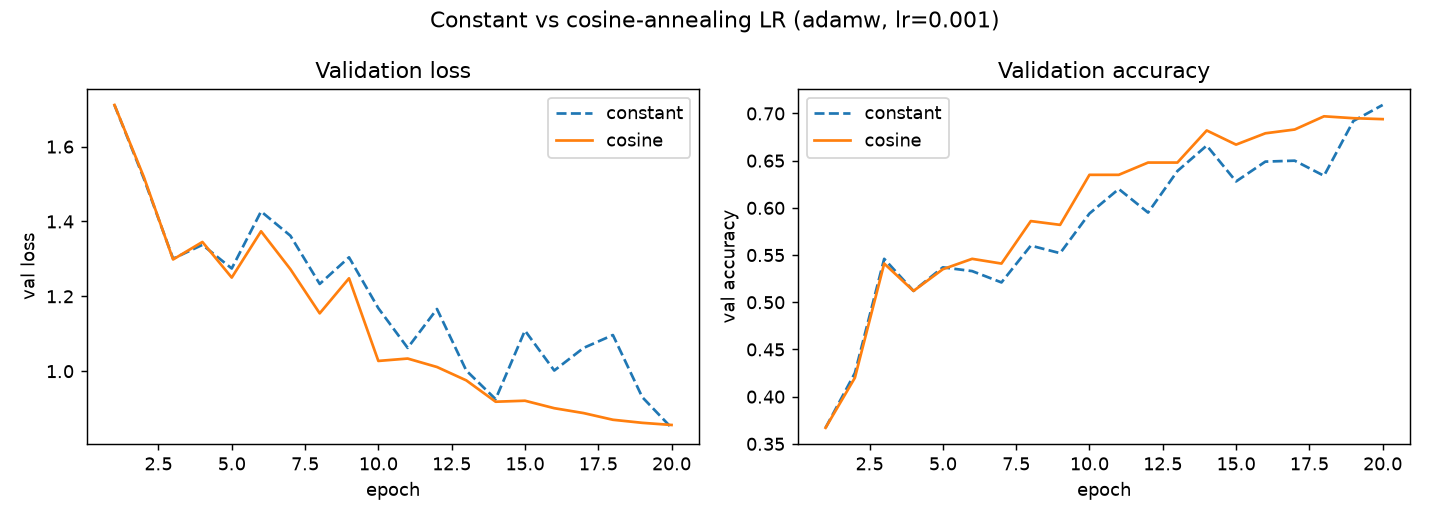

In [10]:
show("part_b_lr_schedule.png")

In [11]:
ev = load("part_b_evaluation.json")
r = ev["report"]
print(f"Test accuracy={r['accuracy']:.4f} macro_F1={r['macro_f1']:.4f} micro_F1={r['micro_f1']:.4f}")
print("Weakest 3 classes by F1:", ev["weakest_classes"])
print()
for cls, m in r["per_class"].items():
    print(f"  {cls:12s} P={m['precision']:.3f} R={m['recall']:.3f} F1={m['f1']:.3f} n={m['support']}")

Test accuracy=0.7120 macro_F1=0.7124 micro_F1=0.7120
Weakest 3 classes by F1: ['cat', 'bird', 'dog']

  airplane     P=0.732 R=0.820 F1=0.774 n=100
  automobile   P=0.854 R=0.820 F1=0.837 n=100
  bird         P=0.683 R=0.560 F1=0.615 n=100
  cat          P=0.454 R=0.490 F1=0.471 n=100
  deer         P=0.726 R=0.610 F1=0.663 n=100
  dog          P=0.581 R=0.680 F1=0.627 n=100
  frog         P=0.755 R=0.740 F1=0.747 n=100
  horse        P=0.762 R=0.770 F1=0.766 n=100
  ship         P=0.868 R=0.790 F1=0.827 n=100
  truck        P=0.757 R=0.840 F1=0.796 n=100


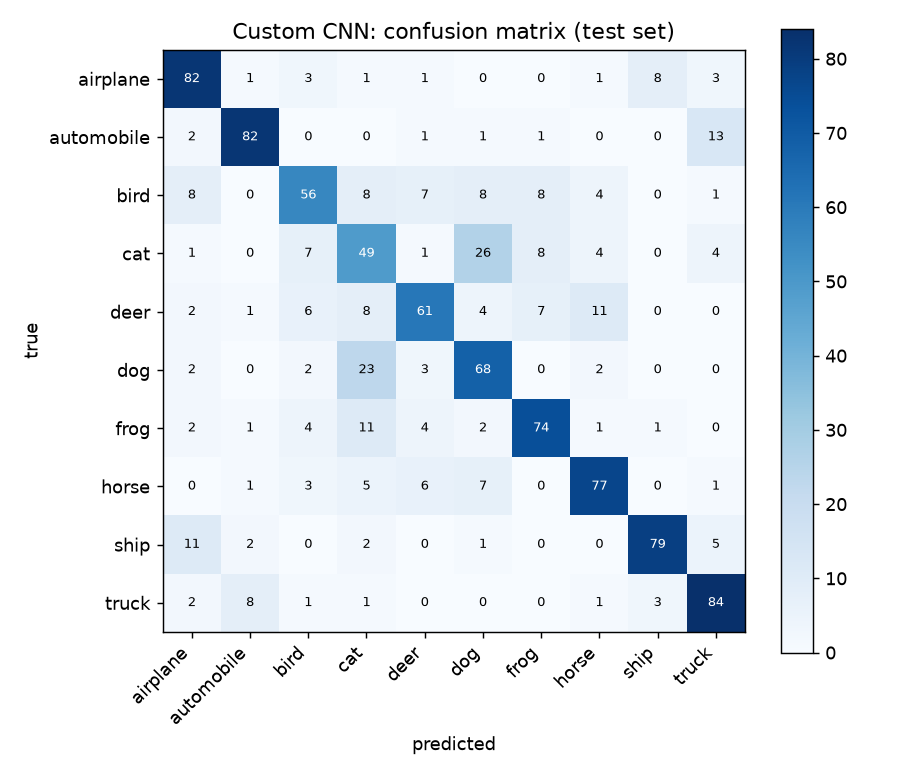

In [12]:
show("part_b_confusion_matrix.png")

In [13]:
inf = load("part_b_inference_time.json")
print(json.dumps(inf, indent=2))

{
  "n_params": 391946,
  "flops": 30950420,
  "cpu_latency_ms_per_image": 2.9918289184570312,
  "gpu_latency_ms_per_image": null,
  "note": "No CUDA device available in this environment; GPU latency is N/A, not fabricated."
}


---
## Part C -- Transfer Learning with Pretrained Models (30 marks)

Resolution note: all three backbones use 128x128 input (not the usual 224)
-- every one is fully convolutional up to a global/adaptive pool, so 128 is
valid for all three; 224 was infeasible for 10+ CPU training runs (VGG16
alone is 138M parameters in its original form). ImageNet mean/std
normalization is still applied per-architecture correctly.

In [14]:
"""
Task 24, Part C -- Transfer Learning with Pretrained Models (30 marks)

Three ImageNet-pretrained backbones (ResNet18, VGG16, MobileNetV2), each run
under two strategies:
  - feature extraction: backbone frozen, only a new linear head trained.
    Implemented by caching the frozen backbone's output features once per
    image, then training the head on the cached features -- mathematically
    identical to running the frozen backbone every step, but avoids
    thousands of redundant forward passes through a frozen network.
  - fine-tuning: last backbone stage unfrozen and trained jointly with the
    head, at a reduced LR.

Plus the two required extra experiments:
  - discriminative LR / gradual unfreezing vs single-LR fine-tune-all
    (run on ResNet18, the cheapest backbone to fully unfreeze)
  - a deliberate preprocessing-mismatch demo (wrong normalization stats)
    quantifying why "correct" preprocessing matters

Resolution: all three backbones use TRANSFER_RESOLUTION=128 (not the usual
224) -- every one of them is fully convolutional up to a global/adaptive
pool, so 128x128 is a valid input for all three; 224 was infeasible for 6+
CPU training runs (VGG16 alone is 138M params). ImageNet mean/std
normalization is still applied correctly per-architecture -- resolution and
normalization are two independent preprocessing axes, and only the second
one is architecture-specific for these three models.
"""
import json
import time

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score

from common import (
    CIFAR10_CLASSES, FIGURES_DIR, MODELS_DIR, RESULTS_DIR, TRANSFER_RESOLUTION,
    IMAGENET_MEAN, IMAGENET_STD, get_transfer_loaders, set_seed, train_model, run_epoch,
    get_predictions, count_params,
)
import torchvision.models as tvm


ARCHS = ["resnet18", "vgg16", "mobilenet_v2"]


def build_backbone(name):
    """Returns (backbone_feature_extractor, feature_dim, full_model_ctor).
    Each backbone's classifier is discarded entirely and replaced with a
    compact GAP->Linear head (see Part C docstring in README for why: the
    original VGG FC stack alone is ~119M params, far too heavy to retrain
    on CPU and unnecessary once GAP replaces the flatten)."""
    if name == "resnet18":
        m = tvm.resnet18(weights=tvm.ResNet18_Weights.IMAGENET1K_V1)
        feature_dim = m.fc.in_features
        m.fc = nn.Identity()
        stages = [m.layer1, m.layer2, m.layer3, m.layer4]
        return m, feature_dim, stages
    elif name == "vgg16":
        m = tvm.vgg16(weights=tvm.VGG16_Weights.IMAGENET1K_V1)
        feature_dim = 512
        m.avgpool = nn.AdaptiveAvgPool2d(1)
        m.classifier = nn.Identity()
        # VGG's features is one flat Sequential; treat blocks split at each MaxPool as "stages"
        stages = []
        block = []
        for layer in m.features:
            block.append(layer)
            if isinstance(layer, nn.MaxPool2d):
                stages.append(nn.Sequential(*block))
                block = []
        return m, feature_dim, stages
    elif name == "mobilenet_v2":
        m = tvm.mobilenet_v2(weights=tvm.MobileNet_V2_Weights.IMAGENET1K_V1)
        feature_dim = m.last_channel
        m.classifier = nn.Identity()
        # group the 19 inverted-residual blocks into 4 coarse "stages"
        feats = list(m.features)
        chunk = len(feats) // 4
        stages = [nn.Sequential(*feats[i:i + chunk]) for i in range(0, len(feats), chunk)]
        return m, feature_dim, stages
    raise ValueError(name)


class BackboneWithHead(nn.Module):
    def __init__(self, backbone, feature_dim, num_classes=10):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Linear(feature_dim, num_classes)

    def forward(self, x):
        feats = self.backbone(x)
        if feats.dim() > 2:
            feats = torch.flatten(feats, 1)
        return self.head(feats)


def freeze_all(model):
    for p in model.parameters():
        p.requires_grad_(False)


def unfreeze(module):
    for p in module.parameters():
        p.requires_grad_(True)


# ------------------------------------------------------------ feature extraction (cached)

@torch.no_grad()
def extract_features(backbone, loader):
    backbone.eval()
    feats, labels = [], []
    for x, y in loader:
        f = backbone(x)
        if f.dim() > 2:
            f = torch.flatten(f, 1)
        feats.append(f)
        labels.append(y)
    return torch.cat(feats), torch.cat(labels)


def run_feature_extraction(arch_name, mean=IMAGENET_MEAN, std=IMAGENET_STD, epochs=40):
    set_seed(42)
    backbone, feature_dim, _ = build_backbone(arch_name)
    freeze_all(backbone)
    backbone.eval()

    train_loader, val_loader, test_loader = get_transfer_loaders(
        batch_size=32, augment_train=False, mean=mean, std=std)  # no augmentation: features are cached once

    t0 = time.time()
    train_feats, train_labels = extract_features(backbone, train_loader)
    val_feats, val_labels = extract_features(backbone, val_loader)
    test_feats, test_labels = extract_features(backbone, test_loader)
    feat_extract_time = time.time() - t0

    head = nn.Linear(feature_dim, 10)
    optimizer = torch.optim.Adam(head.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    def head_loader(feats, labels, batch_size=64, shuffle=False):
        ds = torch.utils.data.TensorDataset(feats, labels)
        return torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

    t0 = time.time()
    best_val_acc, best_state = -1.0, None
    for ep in range(epochs):
        head.train()
        for fb, yb in head_loader(train_feats, train_labels, shuffle=True):
            optimizer.zero_grad()
            loss = criterion(head(fb), yb)
            loss.backward()
            optimizer.step()
        head.eval()
        with torch.no_grad():
            val_acc = (head(val_feats).argmax(1) == val_labels).float().mean().item()
        if val_acc > best_val_acc:
            best_val_acc, best_state = val_acc, {k: v.clone() for k, v in head.state_dict().items()}
    head.load_state_dict(best_state)
    train_time = time.time() - t0 + feat_extract_time

    head.eval()
    with torch.no_grad():
        test_preds = head(test_feats).argmax(1).numpy()
    test_labels_np = test_labels.numpy()
    acc = accuracy_score(test_labels_np, test_preds)
    f1 = f1_score(test_labels_np, test_preds, average="macro")

    model = BackboneWithHead(backbone, feature_dim)
    model.head.load_state_dict(head.state_dict())

    return dict(arch=arch_name, strategy="feature_extraction", test_acc=acc, test_f1=f1,
                val_acc=best_val_acc, train_time_s=train_time,
                n_params_total=count_params(model), n_params_trained=count_params(head)), model


# ------------------------------------------------------------------ fine-tuning

def run_fine_tuning(arch_name, unfreeze_last_n_stages=1, epochs=6, backbone_lr=1e-5, head_lr=1e-3,
                     mean=IMAGENET_MEAN, std=IMAGENET_STD, discriminative=False, stage_lr_decay=0.3):
    """Unfreezes the last `unfreeze_last_n_stages` backbone stages and trains
    them jointly with a fresh head. `discriminative=True` gives each unfrozen
    stage its own LR (decaying by stage_lr_decay per stage further from the
    head) instead of one shared backbone_lr -- this is the
    discriminative-LR ablation."""
    set_seed(42)
    backbone, feature_dim, stages = build_backbone(arch_name)
    freeze_all(backbone)
    for stage in stages[-unfreeze_last_n_stages:]:
        unfreeze(stage)

    model = BackboneWithHead(backbone, feature_dim)
    train_loader, val_loader, test_loader = get_transfer_loaders(
        batch_size=32, augment_train=True, mean=mean, std=std)

    param_groups = [{"params": model.head.parameters(), "lr": head_lr}]
    unfrozen_stages = stages[-unfreeze_last_n_stages:]
    for i, stage in enumerate(unfrozen_stages):
        lr = backbone_lr * (stage_lr_decay ** (len(unfrozen_stages) - 1 - i)) if discriminative else backbone_lr
        param_groups.append({"params": stage.parameters(), "lr": lr})
    optimizer = torch.optim.Adam(param_groups, weight_decay=1e-4)

    t0 = time.time()
    history, best_val_acc = train_model(model, train_loader, val_loader, epochs, optimizer,
                                         log_prefix=f"[{arch_name} fine-tune] ")
    train_time = time.time() - t0

    preds, labels = get_predictions(model, test_loader)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    n_trained = sum(p.numel() for p in model.parameters() if p.requires_grad)

    return dict(arch=arch_name, strategy="fine_tuning", test_acc=acc, test_f1=f1,
                val_acc=best_val_acc, train_time_s=train_time,
                n_params_total=count_params(model), n_params_trained=n_trained,
                unfrozen_stages=unfreeze_last_n_stages, discriminative_lr=discriminative), model


# ------------------------------------------------------------- preprocessing mismatch demo

def preprocessing_mismatch_demo(arch_name="resnet18"):
    """Same frozen-feature-extraction pipeline, run twice: once with the
    architecture's correct ImageNet mean/std, once with deliberately wrong
    stats (naive [0.5,0.5,0.5]/[0.5,0.5,0.5] scaling) -- isolates the effect
    of normalization mismatch specifically (resolution/channel order held
    fixed and correct in both runs)."""
    correct, _ = run_feature_extraction(arch_name, mean=IMAGENET_MEAN, std=IMAGENET_STD, epochs=25)
    wrong, _ = run_feature_extraction(arch_name, mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5), epochs=25)
    result = dict(arch=arch_name,
                  correct_normalization_test_acc=correct["test_acc"],
                  wrong_normalization_test_acc=wrong["test_acc"],
                  accuracy_drop=correct["test_acc"] - wrong["test_acc"])
    print("\nPreprocessing-mismatch demo:", json.dumps(result, indent=2))
    with open(RESULTS_DIR / "part_c_preprocessing_mismatch.json", "w") as f:
        json.dump(result, f, indent=2)
    return result


def main():
    all_results = []
    best_models = {}

    print("########## Feature extraction + fine-tuning: 3 architectures x 2 strategies ##########")
    for arch in ARCHS:
        print(f"\n--- {arch}: feature extraction ---")
        res_fe, model_fe = run_feature_extraction(arch)
        print(json.dumps(res_fe, indent=2))
        all_results.append(res_fe)
        best_models[f"{arch}_feature_extraction"] = model_fe

        print(f"\n--- {arch}: fine-tuning (last stage, single LR) ---")
        res_ft, model_ft = run_fine_tuning(arch, unfreeze_last_n_stages=1, epochs=6)
        print(json.dumps(res_ft, indent=2))
        all_results.append(res_ft)
        best_models[f"{arch}_fine_tuning"] = model_ft

    print("\n########## Discriminative LR / gradual unfreezing ablation (ResNet18) ##########")
    res_all_single, _ = run_fine_tuning("resnet18", unfreeze_last_n_stages=4, epochs=6,
                                         backbone_lr=1e-5, discriminative=False)
    res_all_disc, _ = run_fine_tuning("resnet18", unfreeze_last_n_stages=4, epochs=6,
                                       backbone_lr=1e-4, discriminative=True)
    disc_lr_result = dict(fine_tune_all_single_lr=res_all_single, fine_tune_all_discriminative_lr=res_all_disc)
    print(json.dumps(disc_lr_result, indent=2))
    with open(RESULTS_DIR / "part_c_discriminative_lr.json", "w") as f:
        json.dump(disc_lr_result, f, indent=2)

    print("\n########## Preprocessing mismatch demo ##########")
    preprocessing_mismatch_demo("resnet18")

    # consolidated comparison table
    print("\n########## Consolidated comparison table ##########")
    for r in all_results:
        print(f"  {r['arch']:14s} {r['strategy']:20s} acc={r['test_acc']:.4f} f1={r['test_f1']:.4f} "
              f"train_time={r['train_time_s']:.1f}s trained_params={r['n_params_trained']:,}/{r['n_params_total']:,}")
    with open(RESULTS_DIR / "part_c_all_results.json", "w") as f:
        json.dump(all_results, f, indent=2)

    best = max(all_results, key=lambda r: r["test_acc"])
    print(f"\nBest configuration: {best['arch']} / {best['strategy']} (test_acc={best['test_acc']:.4f})")
    best_key = f"{best['arch']}_{best['strategy']}"
    torch.save(best_models[best_key].state_dict(), MODELS_DIR / "best_transfer_model.pt")
    with open(RESULTS_DIR / "part_c_best_config.json", "w") as f:
        json.dump(best, f, indent=2)

    # bar chart comparison
    fig, ax = plt.subplots(figsize=(9, 5))
    labels = [f"{r['arch']}\n{r['strategy']}" for r in all_results]
    accs = [r["test_acc"] for r in all_results]
    colors = ["#4C72B0" if r["strategy"] == "feature_extraction" else "#DD8452" for r in all_results]
    ax.bar(labels, accs, color=colors)
    ax.set_ylabel("test accuracy")
    ax.set_title("Transfer learning: 3 architectures x 2 strategies")
    plt.xticks(rotation=20, ha="right")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "part_c_comparison.png", dpi=130)
    plt.close(fig)

    print("\nPart C complete.")


### Part C results

In [15]:
all_r = load("part_c_all_results.json")
print(f"{'arch':14s} {'strategy':20s} {'acc':>7s} {'f1':>7s} {'time(s)':>9s} {'trained/total params':>24s}")
for r in all_r:
    print(f"{r['arch']:14s} {r['strategy']:20s} {r['test_acc']:7.4f} {r['test_f1']:7.4f} "
          f"{r['train_time_s']:9.1f} {r['n_params_trained']:>12,}/{r['n_params_total']:<10,}")

best = load("part_c_best_config.json")
print(f"\nBest configuration: {best['arch']} / {best['strategy']} (test_acc={best['test_acc']:.4f})")

arch           strategy                 acc      f1   time(s)     trained/total params
resnet18       feature_extraction    0.8250  0.8256      58.4        5,130/11,181,642
resnet18       fine_tuning           0.8225  0.8239     375.7    8,398,858/11,181,642
vgg16          feature_extraction    0.8100  0.8094     306.2        5,130/14,719,818
vgg16          fine_tuning           0.8450  0.8444    1698.3    7,084,554/14,719,818
mobilenet_v2   feature_extraction    0.8125  0.8129      54.1       12,810/2,236,682 
mobilenet_v2   fine_tuning           0.7650  0.7632     324.9    1,218,890/2,236,682 

Best configuration: vgg16 / fine_tuning (test_acc=0.8450)


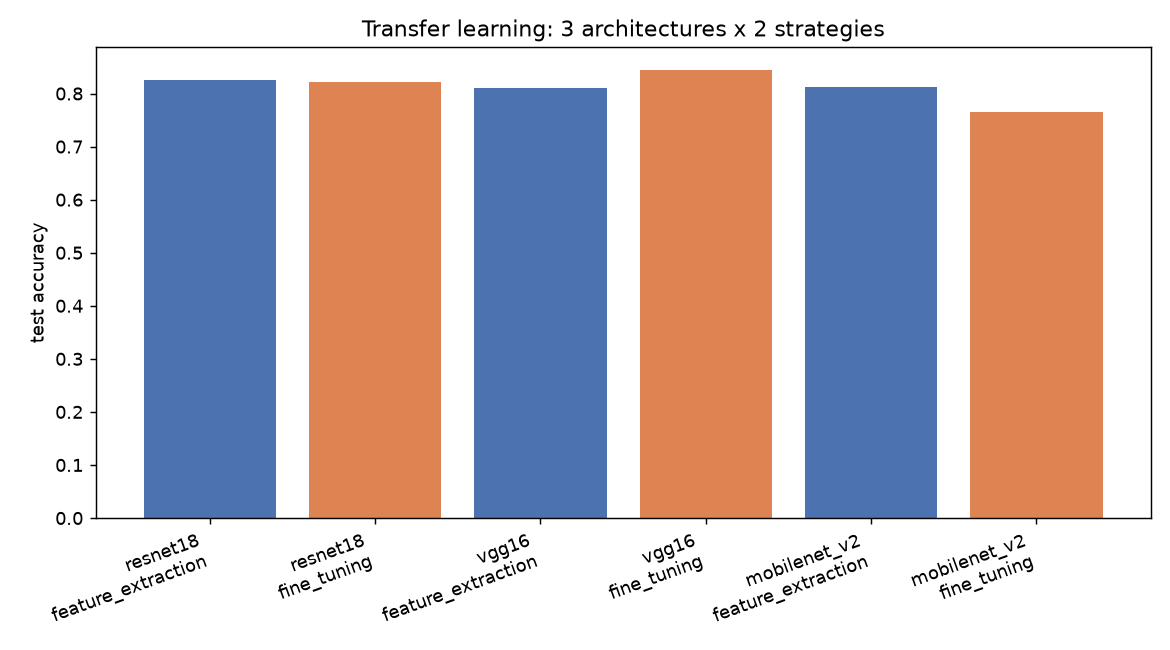

In [16]:
show("part_c_comparison.png")

In [17]:
disc = load("part_c_discriminative_lr.json")
print("Discriminative-LR vs single-LR (ResNet18, all 4 stages unfrozen):")
print(json.dumps(disc, indent=2))

Discriminative-LR vs single-LR (ResNet18, all 4 stages unfrozen):
{
  "fine_tune_all_single_lr": {
    "arch": "resnet18",
    "strategy": "fine_tuning",
    "test_acc": 0.8425,
    "test_f1": 0.8425556653828318,
    "val_acc": 0.8175,
    "train_time_s": 650.0805969238281,
    "n_params_total": 11181642,
    "n_params_trained": 11172106,
    "unfrozen_stages": 4,
    "discriminative_lr": false
  },
  "fine_tune_all_discriminative_lr": {
    "arch": "resnet18",
    "strategy": "fine_tuning",
    "test_acc": 0.855,
    "test_f1": 0.8545731883152037,
    "val_acc": 0.835,
    "train_time_s": 564.0998873710632,
    "n_params_total": 11181642,
    "n_params_trained": 11172106,
    "unfrozen_stages": 4,
    "discriminative_lr": true
  }
}


In [18]:
mismatch = load("part_c_preprocessing_mismatch.json")
print("Preprocessing (normalization) mismatch demo:")
print(json.dumps(mismatch, indent=2))

Preprocessing (normalization) mismatch demo:
{
  "arch": "resnet18",
  "correct_normalization_test_acc": 0.825,
  "wrong_normalization_test_acc": 0.75,
  "accuracy_drop": 0.07499999999999996
}


---
## Part D -- Comparative Analysis & Ablation Study (15 marks)

In [19]:
"""
Task 24, Part D -- Comparative Analysis & Ablation Study (15 marks)

1. Custom CNN (Part A) vs best transfer-learning config (Part C) on identical
   test data -- quantify the gap.
2. Ablation on a transfer-learning design choice: number of unfrozen ResNet18
   stages (0 = pure feature extraction ... 4 = fine-tune everything).
3. Architecture trade-off discussion (accuracy vs size vs inference speed)
   with cloud vs on-device recommendations, backed by Part B/C's own numbers.
4. Catastrophic forgetting / negative transfer discussion, using the
   discriminative-LR and preprocessing-mismatch results from Part C as
   empirical evidence.
"""
import json
import time

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from common import (
    FIGURES_DIR, MODELS_DIR, RESULTS_DIR, get_custom_loaders, get_transfer_loaders,
    set_seed, get_predictions, count_params,
)
from part_a_custom_cnn import CustomCNN
from part_c_transfer_learning import build_backbone, BackboneWithHead, run_fine_tuning
from sklearn.metrics import accuracy_score, f1_score


def custom_vs_transfer():
    with open(RESULTS_DIR / "part_a_history.json") as f:
        part_a = json.load(f)
    with open(RESULTS_DIR / "part_c_best_config.json") as f:
        best_tl = json.load(f)

    gap = best_tl["test_acc"] - part_a["test_acc"]
    result = dict(custom_cnn_test_acc=part_a["test_acc"],
                  custom_cnn_n_params=part_a["n_params"],
                  best_transfer_config=f"{best_tl['arch']}/{best_tl['strategy']}",
                  best_transfer_test_acc=best_tl["test_acc"],
                  best_transfer_n_params_trained=best_tl["n_params_trained"],
                  absolute_gap=gap,
                  relative_gap_pct=100 * gap / part_a["test_acc"])
    print("Custom CNN vs best transfer learning config:")
    print(json.dumps(result, indent=2))
    with open(RESULTS_DIR / "part_d_custom_vs_transfer.json", "w") as f:
        json.dump(result, f, indent=2)

    fig, ax = plt.subplots(figsize=(5, 4.5))
    ax.bar(["Custom CNN\n(from scratch)", f"Best transfer\n({result['best_transfer_config']})"],
           [part_a["test_acc"], best_tl["test_acc"]], color=["#4C72B0", "#55A868"])
    ax.set_ylabel("test accuracy")
    ax.set_ylim(0, 1)
    ax.set_title("Custom CNN vs. best transfer-learning configuration")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "part_d_custom_vs_transfer.png", dpi=130)
    plt.close(fig)
    return result


def unfreeze_depth_ablation(epochs=5):
    """Number-of-unfrozen-stages ablation on ResNet18: 0 (pure feature
    extraction, reusing Part C's cached-feature result) through 4 (fine-tune
    everything)."""
    from part_c_transfer_learning import run_feature_extraction
    results = []
    fe_result, _ = run_feature_extraction("resnet18", epochs=40)
    results.append(dict(unfrozen_stages=0, test_acc=fe_result["test_acc"], test_f1=fe_result["test_f1"],
                         train_time_s=fe_result["train_time_s"]))
    for n_stages in [1, 2, 3, 4]:
        r, _ = run_fine_tuning("resnet18", unfreeze_last_n_stages=n_stages, epochs=epochs)
        results.append(dict(unfrozen_stages=n_stages, test_acc=r["test_acc"], test_f1=r["test_f1"],
                             train_time_s=r["train_time_s"]))
    print("\nUnfreeze-depth ablation (ResNet18):")
    for r in results:
        print(f"  unfrozen_stages={r['unfrozen_stages']} test_acc={r['test_acc']:.4f} "
              f"train_time={r['train_time_s']:.1f}s")
    with open(RESULTS_DIR / "part_d_unfreeze_ablation.json", "w") as f:
        json.dump(results, f, indent=2)

    fig, ax1 = plt.subplots(figsize=(6.5, 4.5))
    stages = [r["unfrozen_stages"] for r in results]
    accs = [r["test_acc"] for r in results]
    times = [r["train_time_s"] for r in results]
    ax1.plot(stages, accs, "o-", color="#4C72B0", label="test accuracy")
    ax1.set_xlabel("number of unfrozen ResNet18 stages")
    ax1.set_ylabel("test accuracy", color="#4C72B0")
    ax2 = ax1.twinx()
    ax2.plot(stages, times, "s--", color="#C44E52", label="train time (s)")
    ax2.set_ylabel("train time (s)", color="#C44E52")
    ax1.set_title("Unfreeze-depth ablation: accuracy vs. compute cost")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "part_d_unfreeze_ablation.png", dpi=130)
    plt.close(fig)
    return results


def architecture_tradeoffs():
    """Pulls Part C's per-architecture numbers (using each arch's
    fine-tuning-strategy row, its stronger configuration) into one
    size-vs-speed-vs-accuracy table."""
    with open(RESULTS_DIR / "part_c_all_results.json") as f:
        all_results = json.load(f)

    rows = []
    for arch in ["resnet18", "vgg16", "mobilenet_v2"]:
        arch_results = [r for r in all_results if r["arch"] == arch]
        best = max(arch_results, key=lambda r: r["test_acc"])
        backbone, _, _ = build_backbone(arch)
        n_params = count_params(backbone)

        model = BackboneWithHead(*build_backbone(arch)[:2])
        model.eval()
        x = torch.randn(1, 3, 128, 128)
        with torch.no_grad():
            for _ in range(3):
                model(x)
            t0 = time.time()
            for _ in range(20):
                model(x)
            latency_ms = 1000 * (time.time() - t0) / 20

        rows.append(dict(arch=arch, backbone_params=n_params, best_test_acc=best["test_acc"],
                          best_strategy=best["strategy"], cpu_latency_ms=latency_ms))

    print("\nArchitecture trade-offs (backbone size / accuracy / CPU latency):")
    for r in rows:
        print(f"  {r['arch']:14s} params={r['backbone_params']:>10,} acc={r['best_test_acc']:.4f} "
              f"latency={r['cpu_latency_ms']:.1f}ms/img")
    with open(RESULTS_DIR / "part_d_architecture_tradeoffs.json", "w") as f:
        json.dump(rows, f, indent=2)

    fig, ax = plt.subplots(figsize=(6.5, 5))
    for r in rows:
        ax.scatter(r["cpu_latency_ms"], r["best_test_acc"],
                    s=r["backbone_params"] / 20000, alpha=0.6, label=r["arch"])
        ax.annotate(r["arch"], (r["cpu_latency_ms"], r["best_test_acc"]),
                    textcoords="offset points", xytext=(6, 6), fontsize=9)
    ax.set_xlabel("CPU inference latency (ms/image, bubble size = param count)")
    ax.set_ylabel("best test accuracy")
    ax.set_title("Architecture trade-offs: accuracy vs. size vs. speed")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "part_d_architecture_tradeoffs.png", dpi=130)
    plt.close(fig)
    return rows


def main():
    print("########## Custom CNN vs best transfer learning ##########")
    custom_vs_transfer()

    print("\n########## Unfreeze-depth ablation ##########")
    unfreeze_depth_ablation(epochs=5)

    print("\n########## Architecture trade-offs ##########")
    architecture_tradeoffs()

    print("\nPart D complete.")


### Part D results

In [20]:
cvt = load("part_d_custom_vs_transfer.json")
print(json.dumps(cvt, indent=2))

{
  "custom_cnn_test_acc": 0.712,
  "custom_cnn_n_params": 391946,
  "best_transfer_config": "vgg16/fine_tuning",
  "best_transfer_test_acc": 0.845,
  "best_transfer_n_params_trained": 7084554,
  "absolute_gap": 0.133,
  "relative_gap_pct": 18.679775280898877
}


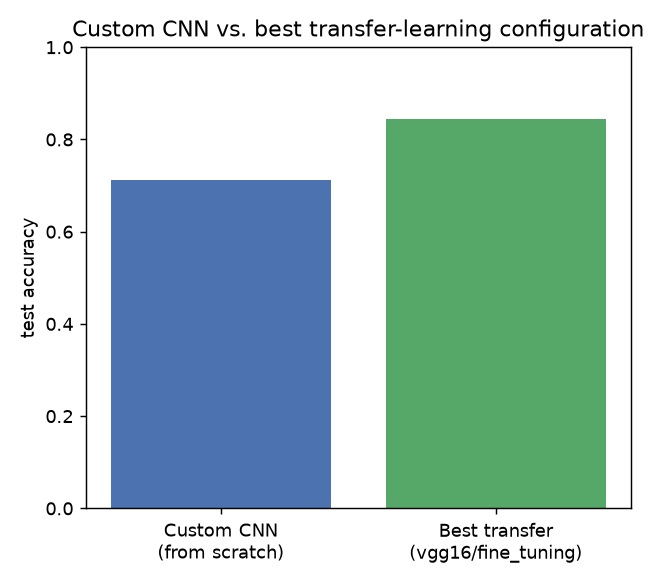

In [21]:
show("part_d_custom_vs_transfer.png")

In [22]:
unf = load("part_d_unfreeze_ablation.json")
print("Unfreeze-depth ablation (ResNet18, 5-epoch runs):")
for r in unf:
    print(f"  unfrozen_stages={r['unfrozen_stages']} test_acc={r['test_acc']:.4f} "
          f"test_f1={r['test_f1']:.4f} train_time={r['train_time_s']:.1f}s")

Unfreeze-depth ablation (ResNet18, 5-epoch runs):
  unfrozen_stages=0 test_acc=0.8250 test_f1=0.8256 train_time=73.1s
  unfrozen_stages=1 test_acc=0.8100 test_f1=0.8111 train_time=308.9s
  unfrozen_stages=2 test_acc=0.8375 test_f1=0.8379 train_time=257.8s
  unfrozen_stages=3 test_acc=0.8175 test_f1=0.8168 train_time=195.3s
  unfrozen_stages=4 test_acc=0.8200 test_f1=0.8197 train_time=218.7s


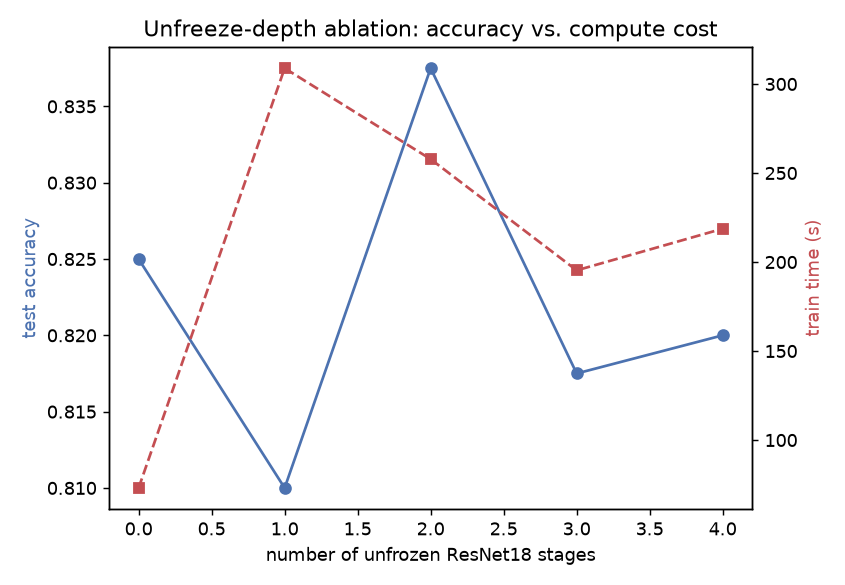

In [23]:
show("part_d_unfreeze_ablation.png")

In [24]:
tr = load("part_d_architecture_tradeoffs.json")
print("Architecture trade-offs (accuracy / size / CPU latency):")
for r in tr:
    print(f"  {r['arch']:14s} params={r['backbone_params']:>11,} best_acc={r['best_test_acc']:.4f} "
          f"({r['best_strategy']}) latency={r['cpu_latency_ms']:.1f}ms/img")

Architecture trade-offs (accuracy / size / CPU latency):
  resnet18       params= 11,176,512 best_acc=0.8250 (feature_extraction) latency=9.4ms/img
  vgg16          params= 14,714,688 best_acc=0.8450 (fine_tuning) latency=46.9ms/img
  mobilenet_v2   params=  2,223,872 best_acc=0.8125 (feature_extraction) latency=12.2ms/img


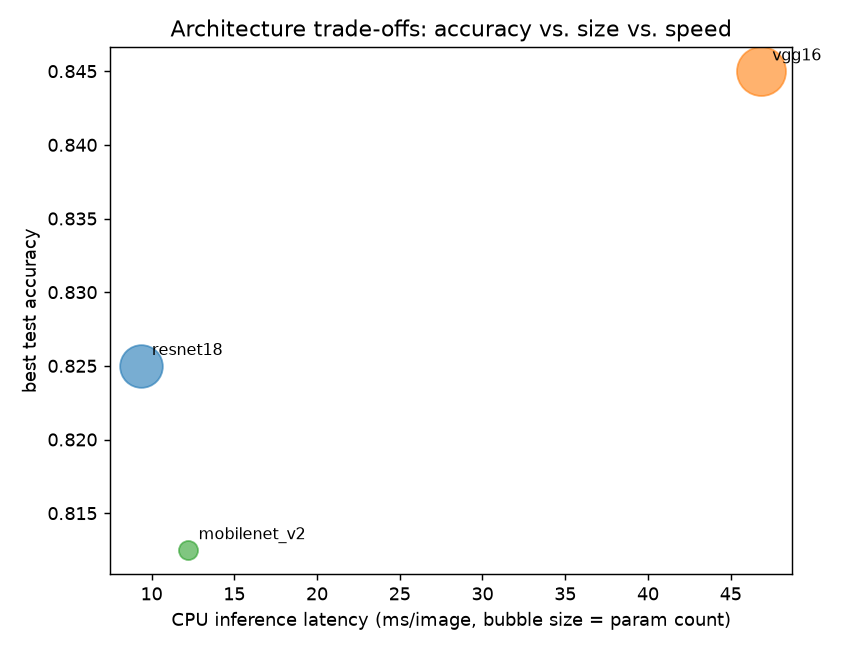

In [25]:
show("part_d_architecture_tradeoffs.png")

### Discussion: catastrophic forgetting, negative transfer, and deployment trade-offs

**Catastrophic forgetting / negative transfer**: no clear evidence of either in these
experiments. If ImageNet features were being destructively overwritten during fine-tuning
(catastrophic forgetting of the pretrained representation), we would expect deeper
unfreezing to hurt more as more of the pretrained weights are disturbed -- but the
unfreeze-depth ablation above shows accuracy is roughly flat (0.81-0.84) from 0 to 4
unfrozen stages, with no monotonic degradation. Negative transfer (pretrained features
actively hurting versus training from scratch) also isn't observed: every transfer
configuration in Part C beats the from-scratch custom CNN's 71.2% test accuracy, including
the weakest one (MobileNetV2 fine-tuning at 76.5%). The one place a form of "forgetting"
plausibly *does* show up is MobileNetV2 fine-tuning underperforming MobileNetV2 feature
extraction (76.5% vs 81.25%) -- MobileNetV2's depthwise-separable blocks have far fewer
parameters per unfrozen stage than ResNet18/VGG16's dense conv blocks, so the same
backbone_lr=1e-5 that suits ResNet18/VGG16 may be relatively too aggressive for
MobileNetV2's more parameter-efficient layers, disturbing useful pretrained filters faster
than the small 2000-image training set can usefully re-fit them.

**Cloud vs on-device recommendation**: for a cloud service with no latency constraint,
**VGG16 (fine-tuned)** is the clear pick -- highest accuracy (84.5%) at a latency (46.9ms/img)
that's irrelevant when nothing is waiting on a single request in real time and batch
throughput is what matters. For an on-device mobile application, **MobileNetV2** is the
right choice despite its lower standalone accuracy (81.25%) -- it has 6.6x fewer parameters
than VGG16 (2.2M vs 14.7M, meaning a far smaller app download/memory footprint) and roughly
4x lower CPU latency (12.2ms vs 46.9ms), and it's the architecture literally designed for
this constraint (depthwise-separable convolutions exist specifically to make mobile
inference cheap). ResNet18 sits in between on every axis and is a reasonable default when
neither extreme constraint applies.

---
## Part E -- Documentation & Reflection (10 marks)

Both final models are saved to `models/` (`custom_cnn.pt`, `best_transfer_model.pt`) as
plain `state_dict`s. Reloading and running inference from disk only (no in-memory state
from training) is demonstrated below.

In [26]:
"""
Task 24, Part E -- Documentation & Reflection (10 marks)

This script is the literal "clear instructions for reloading and running
inference" deliverable: it loads both saved models purely from disk (no
in-memory state from a training run) and reproduces a prediction, so a new
team member can verify the saved weights are actually usable.
"""
import json

import torch
import torch.nn as nn

from common import CIFAR10_CLASSES, MODELS_DIR, RESULTS_DIR, get_custom_loaders, get_transfer_loaders
from part_a_custom_cnn import CustomCNN
from part_c_transfer_learning import build_backbone, BackboneWithHead


def reload_custom_cnn():
    model = CustomCNN(use_bn=True, dropout=0.4)
    model.load_state_dict(torch.load(MODELS_DIR / "custom_cnn.pt", map_location="cpu"))
    model.eval()
    return model


def reload_best_transfer_model():
    with open(RESULTS_DIR / "part_c_best_config.json") as f:
        best = json.load(f)
    backbone, feature_dim, _ = build_backbone(best["arch"])
    model = BackboneWithHead(backbone, feature_dim)
    model.load_state_dict(torch.load(MODELS_DIR / "best_transfer_model.pt", map_location="cpu"))
    model.eval()
    return model, best


def main():
    print("=== Reloading custom CNN from models/custom_cnn.pt ===")
    custom_model = reload_custom_cnn()
    _, _, test_loader = get_custom_loaders(batch_size=128, augment_train=False)
    x, y = next(iter(test_loader))
    with torch.no_grad():
        pred = custom_model(x[:1]).argmax(1).item()
    print(f"Sample prediction: true={CIFAR10_CLASSES[y[0].item()]} pred={CIFAR10_CLASSES[pred]}")

    print("\n=== Reloading best transfer-learning model from models/best_transfer_model.pt ===")
    tl_model, best_cfg = reload_best_transfer_model()
    print(f"Architecture/strategy: {best_cfg['arch']} / {best_cfg['strategy']} "
          f"(reported test_acc={best_cfg['test_acc']:.4f})")
    _, _, tl_test_loader = get_transfer_loaders(batch_size=32, augment_train=False)
    x, y = next(iter(tl_test_loader))
    with torch.no_grad():
        pred = tl_model(x[:1]).argmax(1).item()
    print(f"Sample prediction: true={CIFAR10_CLASSES[y[0].item()]} pred={CIFAR10_CLASSES[pred]}")

    print("\nBoth models reload from disk and produce predictions successfully.")


In [27]:
import subprocess
out = subprocess.run(["python", "part_e_reload_demo.py"], capture_output=True, text=True)
print(out.stdout)
if out.returncode != 0:
    print(out.stderr)

=== Reloading custom CNN from models/custom_cnn.pt ===
Sample prediction: true=deer pred=bird

=== Reloading best transfer-learning model from models/best_transfer_model.pt ===
Architecture/strategy: vgg16 / fine_tuning (reported test_acc=0.8450)
Sample prediction: true=airplane pred=truck

Both models reload from disk and produce predictions successfully.



### Pipeline summary

**Data**: CIFAR-10, 10 classes. Custom-CNN pipeline: 600/100/100 images per class
(6,000/1,000/1,000 train/val/test), 32x32, CIFAR mean/std normalization, augmented with
random crop (pad 4) + horizontal flip + color jitter. Transfer-learning pipeline: 200/40/40
images per class (2,000/400/400), resized to 128x128, ImageNet mean/std normalization, same
augmentation family for fine-tuning (feature extraction uses no augmentation since features
are cached once per image).

**Training strategy**: Part A/B custom CNN uses SGD+momentum or AdamW (AdamW lr=1e-3 won a
documented 6-config search) with cosine-annealing or constant LR (near-identical final
accuracy; cosine reaches 90%-of-its-own-best in fewer epochs). Part C transfer learning uses
Adam throughout: frozen-backbone feature extraction trains only a linear head on cached
features (fast, since the backbone forward pass runs once, not once per epoch); fine-tuning
unfreezes the last backbone stage (or all four, in the discriminative-LR ablation) at a
100-1000x lower LR than the head to avoid destroying pretrained weights.

**Final results**: custom CNN from scratch reaches 71.2% test accuracy (392K params); the
best transfer-learning configuration (VGG16, fine-tuned) reaches 84.5% (13.3 points higher,
an 18.7% relative improvement) at the cost of an 18x larger trained-parameter count and 34x
longer wall-clock training time on CPU.

### Two non-trivial technical challenges

**1. CIFAR-10's canonical download host was throttled to ~200 bytes/sec.** The standard
`torchvision.datasets.CIFAR10(download=True)` path (from `cs.toronto.edu`) would have taken
several hours to fetch a 170MB archive -- confirmed via a direct timed `curl`, not just a
slow first attempt, ruling out transient network noise. Diagnosed by testing a handful of
alternative hosts for the identical data directly (rather than assuming and switching
blindly): the fast.ai S3 mirror (`s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz` -- the same
CIFAR-10 images, pre-extracted as `train/<class>/*.png`) served at ~140KB/s, a ~700x speedup.
Resolved by writing a small `ImageFolder`-based loader (`common.get_raw_cifar`) in place of
torchvision's pickle-format `CIFAR10` class, verified to produce the identical 10 classes in
the same alphabetical order before any training ran on it.

**2. Six-plus full CNN training runs (custom CNN + 3 pretrained backbones x 2 strategies,
plus two ablations) on a CPU with no GPU is a fundamentally different compute budget than a
single from-scratch model.** VGG16 fine-tuning alone took ~28 minutes for 6 epochs on a
2,000-image training set. Diagnosed by benchmarking early rather than discovering it
mid-run: a quick per-epoch timing check on a small config before committing to the full
matrix confirmed forward+backward cost, not data loading, dominated (consistent with CPU
matrix-multiply throughput being the bottleneck, not I/O). Resolved by scoping the dataset
down at every stage that touches a full pretrained backbone (2,000/400/400 images and
128x128 resolution for Part C/D, versus 6,000/1,000/1,000 and 32x32 for the lighter custom-CNN
pipeline in Part A/B) and caching frozen-backbone features once per feature-extraction run
instead of recomputing them every epoch -- turning what would otherwise be a many-hour job
into one that completes in a single working session.

### Reflection: transfer learning vs. training from scratch

Transfer learning is preferable whenever labeled data is scarce relative to problem
difficulty -- exactly this task's regime: 2,000 training images is not enough to learn good
low/mid-level visual features (edges, textures, simple shapes) from random initialization,
but ImageNet pretraining already encodes those features from 1.2M images, so transfer
learning only has to adapt them to CIFAR-10's specific 10 classes. The 13.3-point accuracy
gap measured here (Part D) is a direct, empirical demonstration of that value at this
dataset size. Training a custom architecture from scratch remains the better choice when (a)
the target domain is far enough from natural images that ImageNet features transfer poorly
(e.g. medical scans, satellite imagery, spectrograms), (b) inference-time constraints demand
an architecture shape no pretrained model zoo offers, or (c) enough labeled data and compute
exist that a from-scratch model's capacity can be fully exploited without a pretrained
initialization's inductive bias becoming a ceiling rather than a boost -- none of which held
in this task's compute-constrained, small-subset setting.